# Imports

In [1]:
# from fastai.vision.all import *
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
import shutil
import re
import os
import pandas as pd
results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_10fold_1rep_1000bal_224px'
method = 'fold'
# use_model = 'densenet169_1fold_1rep_10933bal_224px'
# method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')

sampleinfo = Path('/mnt/sampleinfo')
slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_44.tsv'),
                       sep='\t',
                       dtype={'slide':'str'}).drop(columns=['Unnamed: 0'])
# slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_76_v3.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
# tile_df = pd.read_csv(sampleinfo.joinpath('tile_df_v8.0_298007_v3.tsv'),
#                       dtype='str',
#                       sep='\t')
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')

In [2]:
def max_best_spec(t,sp,a):
    a = np.array(a)
    sp = np.array(sp)
    t0=t[np.argwhere(sp==np.max(sp))[0]]
    ti=np.argwhere(sp==np.max(sp))
    a0 = a[ti[0]]
    an = a0
    i=0
    while (an >= a0) and ((i+1) < len(ti)):
        i = i +1
        an = a[ti[i]]
        
    return t[ti[i-1]]

#  Run FULL inference on trained models (ALL TILES)
see : /model_fitting/infer/fastai_cnn_cv_train_inference_v8.py


# Load all inference outputs, eval model performance 

In [4]:
ifn = [str(x) for x in infer_path.glob('*.csv')]
folds = len(ifn)
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
def geo_mean(iterable):
    a = np.array(iterable)
    return a.prod()**(1.0/len(a))
all_y_true = []
all_y_pred = []

for fold in range(0,folds):
    fn = infer_path.joinpath('%s_%d_all_valid_pred.csv' % (method,fold))
    if fn.exists():
        df=pd.read_csv(fn,dtype={'slide':'str'})        
        u_slide = df.slide.unique()
        # fold_slides.extend(u_slide)
        for slide in u_slide:
            idx = slide_df.slide.str.contains(str(slide))
            slide_idx = df.slide.str.contains(str(slide))
            # cls_type = slide_df.loc[idx,'anno_class'].str.contains('malig').values
            tile_p = df.loc[slide_idx,'p_pos'].values
            all_y_pred.extend(tile_p)
            tile_cls= df.loc[slide_idx,'slide_class'].str.contains('malig').values
            all_y_true.extend(tile_cls)
            m_p = np.mean(tile_p)
            valid.loc[idx,'fold']=fold
            valid.loc[idx,'mean_p_pos'] = m_p
            valid.loc[idx,'median_p_pos'] = np.median(tile_p)
            valid.loc[idx,'fraction_pos'] = np.sum(tile_p>0.5)/len(tile_p)
valid.head()

,slide,group,class,accession_number,fold,mean_p_pos,median_p_pos,fraction_pos
0,1007831,malignant,True,PHS15-7377 - 1007831,9.0,0.055811,0.000085,0.048444
1,1010330,benign,False,PHS15-7510 - 1010330,4.0,0.197808,0.001750,0.190141
2,1007828,malignant,True,PHS15-9836 - 1007828,3.0,0.123999,0.000639,0.116306
3,1010333,benign,False,PHS15-29884 - 1010333,6.0,0.085682,0.001667,0.069422
4,1010328,benign,False,PHS16-5752 - 1010328,1.0,0.015763,0.000154,0.008929


Best spec [0.25]


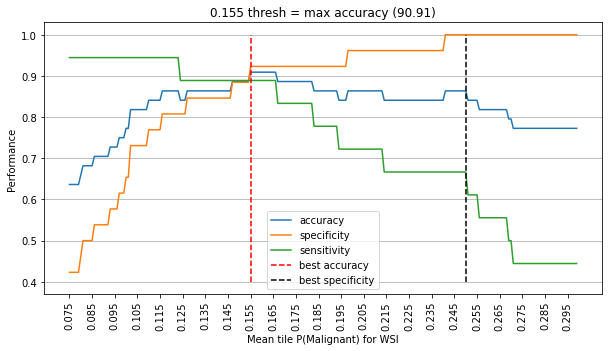

In [6]:
a = []
sp = []
sn = []
t = np.arange(0.075,0.3,0.001)
y_true = valid.loc[:,'class'].values
for i in t:
    y_pred = valid.mean_p_pos.values > i
    c = np.sum(y_true == y_pred)
    cm = skm.confusion_matrix(y_true, y_pred)
    accuracy = c/len(y_true)
    a.append(accuracy)
    specificity = cm[0,0] / np.sum(cm,axis=1)[0]
    sp.append(specificity)
    sensitivity = cm[1,1] /  np.sum(cm,axis=1)[1]
    sn.append(sensitivity)
    
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(t,a,label='accuracy')
best_t = t[np.argwhere(a==np.max(a))[0]]
ax.set_title('%1.3f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

ax.plot(t,sp,label='specificity')
ax.plot(t,sn,label='sensitivity')
plt.xticks(np.arange(0.075,0.3,0.01),rotation=90)
ax.plot([best_t,best_t],[0.4,1],'--r',label='best accuracy')

best_spec = max_best_spec(t,sp,a)
ax.plot([best_spec,best_spec],[0.4,1],'--k',label='best specificity')
ax.set_ylabel('Performance')
ax.set_xlabel('Mean tile P(Malignant) for WSI')
ax.legend()
plt.grid(axis='y')
print('Best spec',best_spec)
# best_t_sp = t[np.argwhere(sp==np.max(sp))[0]]
# plt.title('%1.2f thresh = max sp (%2.2f)' % (best_t_sp, np.max(sp)*100))

# plt.plot(t,a)
# best_t = t[np.argwhere(a==np.max(a))[0]]
# plt.title('%1.2f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

In [13]:
def vector_to_quantile_index(dat,num_quantiles):
    nq=num_quantiles
    N = len(dat)
    o = dat.argpartition(np.arange(1, nq) * N // nq)
    out = np.empty(N, int)
    out[o] = np.arange(N) * nq // N
    return out

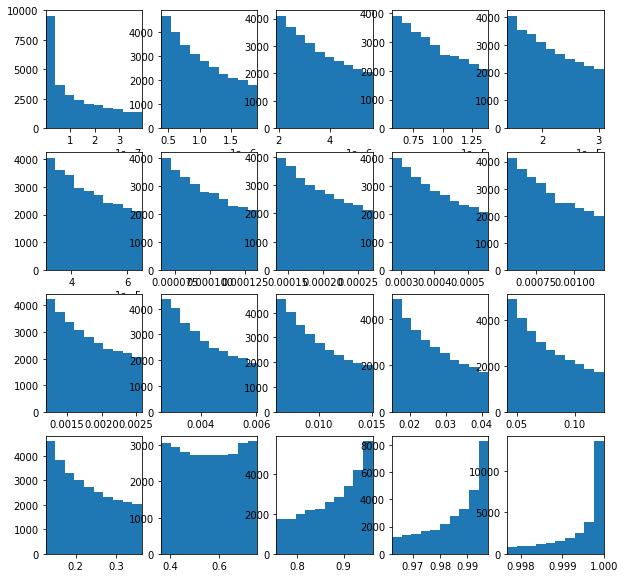

In [42]:
all_p=np.array(all_y_pred)
# plt.figure()
# plt.hist(all_p[(all_p < 0.1) & (all_p > 1e-3)],np.arange(0,0.1,0.001));
# plt.figure()
# plt.hist(all_p[all_p > 0.9],np.arange(0.9,1,0.001));
nq = 20
out = vector_to_quantile_index(all_p,nq)
fig = plt.figure(figsize=(10,10))
quant_bin=[]
for q in range(0,nq):
    ax = fig.add_subplot(4,5,abs(q+1))
    dat = all_p[out==q]
    ax.hist(dat)
    bins=[np.min(dat),np.max(dat)]
    quant_bin.append(bins)
    ax.set_xlim(bins)

In [43]:
print(bins)

[0.9976751, 1.0]


# Overtrained performance plots

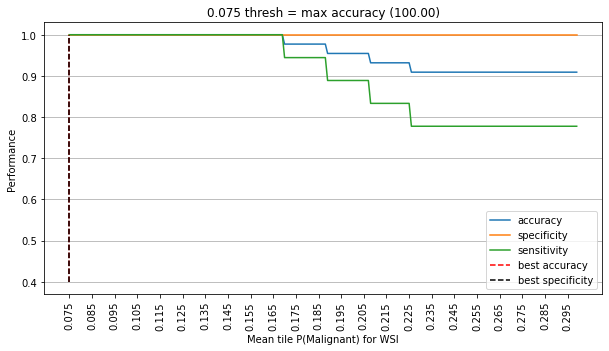

In [4]:
a = []
sp = []
sn = []
t = np.arange(0.075,0.3,0.001)
y_true = valid.loc[:,'class'].values
for i in t:
    y_pred = valid.mean_p_pos.values > i
    c = np.sum(y_true == y_pred)
    cm = skm.confusion_matrix(y_true, y_pred)
    accuracy = c/len(y_true)
    a.append(accuracy)
    specificity = cm[0,0] / np.sum(cm,axis=1)[0]
    sp.append(specificity)
    sensitivity = cm[1,1] /  np.sum(cm,axis=1)[1]
    sn.append(sensitivity)
    
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(t,a,label='accuracy')
best_t = t[np.argwhere(a==np.max(a))[0]]
ax.set_title('%1.3f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

ax.plot(t,sp,label='specificity')
ax.plot(t,sn,label='sensitivity')
plt.xticks(np.arange(0.075,0.3,0.01),rotation=90)
ax.plot([best_t,best_t],[0.4,1],'--r',label='best accuracy')

best_spec = t[np.argwhere(sp==np.max(sp))[0]]
ax.plot([best_spec,best_spec],[0.4,1],'--k',label='best specificity')
ax.set_ylabel('Performance')
ax.set_xlabel('Mean tile P(Malignant) for WSI')
ax.legend()
plt.grid(axis='y')
# best_t_sp = t[np.argwhere(sp==np.max(sp))[0]]
# plt.title('%1.2f thresh = max sp (%2.2f)' % (best_t_sp, np.max(sp)*100))

# plt.plot(t,a)
# best_t = t[np.argwhere(a==np.max(a))[0]]
# plt.title('%1.2f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))


45 45


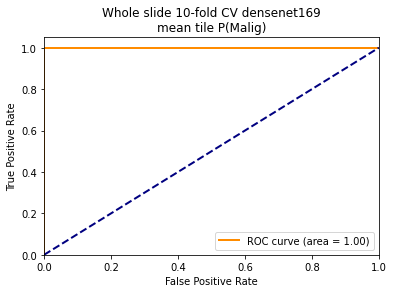

In [5]:
y_score = valid.mean_p_pos.values
y_true = valid.loc[:,'group'].str.contains('malig').astype(int).values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide 10-fold CV densenet169\nmean tile P(Malig)")
plt.legend(loc="lower right")
plt.show()


Thresh [0.155] 
Accuracy 0.9090909090909091 
Specificity 0.9230769230769231 
Sensitivity 0.8888888888888888
Thresh [0.25] 
Accuracy 0.8636363636363636 
Specificity 1.0 
Sensitivity 0.6666666666666666


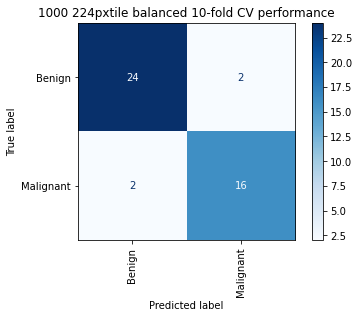

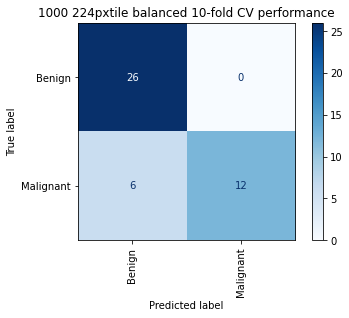

In [7]:
norm = False
use_t = best_t
use_t = 0.245
threshes = [best_t, best_spec]
for use_t in threshes:
    y_true =  valid.loc[:,'class'].values
    y_pred = valid.mean_p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

# True 10-fold CV performance plots

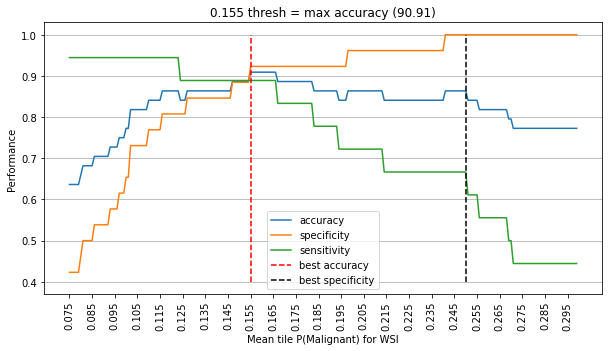

In [8]:
a = []
sp = []
sn = []
t = np.arange(0.075,0.3,0.001)
y_true = valid.loc[:,'class'].values
for i in t:
    y_pred = valid.mean_p_pos.values > i
    c = np.sum(y_true == y_pred)
    cm = skm.confusion_matrix(y_true, y_pred)
    accuracy = c/len(y_true)
    a.append(accuracy)
    specificity = cm[0,0] / np.sum(cm,axis=1)[0]
    sp.append(specificity)
    sensitivity = cm[1,1] /  np.sum(cm,axis=1)[1]
    sn.append(sensitivity)
    
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(t,a,label='accuracy')
best_t = t[np.argwhere(a==np.max(a))[0]]
ax.set_title('%1.3f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

ax.plot(t,sp,label='specificity')
ax.plot(t,sn,label='sensitivity')
plt.xticks(np.arange(0.075,0.3,0.01),rotation=90)
ax.plot([best_t,best_t],[0.4,1],'--r',label='best accuracy')

best_spec = max_best_spec(t,sp,a)
ax.plot([best_spec,best_spec],[0.4,1],'--k',label='best specificity')
ax.set_ylabel('Performance')
ax.set_xlabel('Mean tile P(Malignant) for WSI')
ax.legend()
plt.grid(axis='y')
# best_t_sp = t[np.argwhere(sp==np.max(sp))[0]]
# plt.title('%1.2f thresh = max sp (%2.2f)' % (best_t_sp, np.max(sp)*100))

# plt.plot(t,a)
# best_t = t[np.argwhere(a==np.max(a))[0]]
# plt.title('%1.2f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))


Thresh [0.155] 
Accuracy 0.9090909090909091 
Specificity 0.9230769230769231 
Sensitivity 0.8888888888888888
Thresh 0.245 
Accuracy 0.8636363636363636 
Specificity 1.0 
Sensitivity 0.6666666666666666


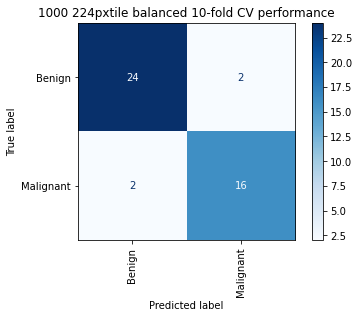

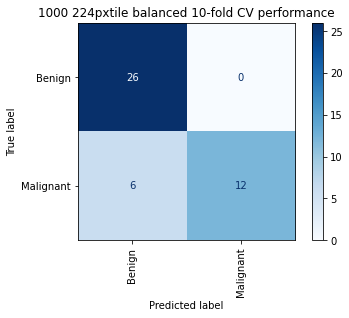

In [6]:
norm = False
use_t = best_t
use_t = 0.245
threshes = [best_t, 0.245]
for use_t in threshes:
    y_true =  valid.loc[:,'class'].values
    y_pred = valid.mean_p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

Thresh [0.155] 
Accuracy 0.905982905982906 
Specificity 0.9230769230769231 
Sensitivity 0.8888888888888888
Thresh [0.25] 
Accuracy 0.8333333333333333 
Specificity 1.0 
Sensitivity 0.6666666666666666


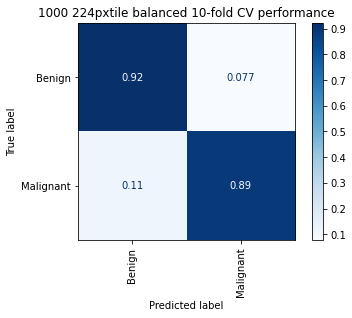

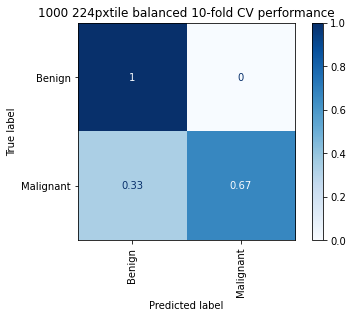

In [11]:
norm = True
threshes = [best_t, best_spec]
for use_t in threshes:
    y_true =  valid.loc[:,'class'].values
    y_pred = valid.mean_p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

In [101]:
fpr

array([0.        , 0.        , 0.        , 0.03846154, 0.03846154,
       0.07692308, 0.07692308, 0.19230769, 0.19230769, 0.61538462,
       0.61538462, 1.        ])

45 45


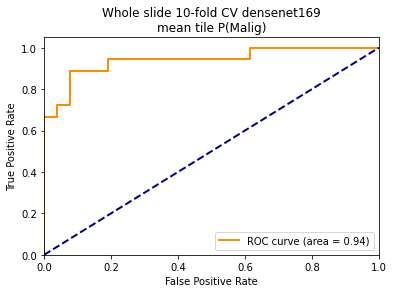

In [7]:
y_score = valid.mean_p_pos.values
y_true = valid.loc[:,'group'].str.contains('malig').astype(int).values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide 10-fold CV densenet169\nmean tile P(Malig)")
plt.legend(loc="lower right")
plt.show()


# Something like --> evaluate tile level ROC.
But! Need to only include annotated positive tiles!

266163 266163


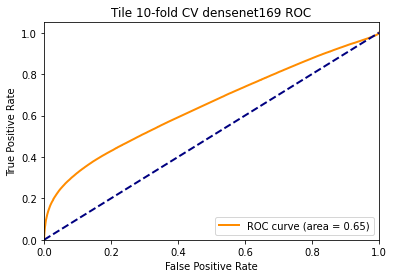

In [9]:
thresh = 0.2
y_score = valid.mean_p_pos.values
y_true = valid.loc[:,'group'].str.contains('malig').astype(int).values
fpr, tpr, thr = skm.roc_curve(all_y_true,
                              all_y_pred)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tile 10-fold CV densenet169 ROC")
plt.legend(loc="lower right")
plt.show()
